In [ ]:

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("healthcare.duckdb")

con.execute("PRAGMA threads=4")
con.execute("SET memory_limit='6GB'")

import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"

fm.fontManager.addfont(font_path)

font_name = fm.FontProperties(fname=font_path).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print(font_name)

Noto Sans CJK JP


                    시장 성장 분석
                          │
             ┌────────────┴────────────┐
             │                         │
        성장 결과                  성장 과정
             │                         │
        CGR / 성장액              추세성 β
                                       │
                              ┌────────┴────────┐
                              │                 │
                           안정적           가속/둔화
                              │                 │
                         R² / 변동성        YoY β(rolling)



                 Trend β
                    ↑
        성장 전환   │   구조적 성장
        CGR<0      │   CGR>0
                    │
────────────────────┼──────────────────→ CGR
                    │
        구조적      │   둔화/하락전환
        하락        │
                    ↓

In [ ]:
# !pip install duckdb numpy pandas matplotlib statsmodels scipy ipython

In [4]:
con.execute("select * from mefi_sick limit 1").df()

,diagYm,meftDivNo,meftDivNoNm,st3SickSym,st3SickSymNm,insupTpCd,totUseQty,msupUseAmt
0,202001,111,전신마취제,AA03,시겔라증,4,2,4024


In [ ]:
# con.execute("select meftDivNo, meftDivNoNm from mefi_region group by 1,2").df().to_csv("약효분류군100.csv")

import pandas as pd

# 1. 파일 불러오기
meft_atc_map = pd.read_csv('raw_data/cmpn_atc_map.txt', delimiter='\t')
meft_atc_map['atc2cd'] = meft_atc_map['AtcCd'].str[:3]
meft_atc_map.drop_duplicates(['meftDivNo','atc2cd'],inplace=True)
meft_atc_map.shape, meft_atc_map.meftDivNo.nunique()



(310, 8)

In [ ]:
test_meft_df = pd.read_csv('약효분류군100.csv')


merged= pd.merge(test_meft_df, meft_atc_map, on='meftDivNo', how='left', indicator=True)
unmatched_df1 = merged[merged['_merge'] == 'left_only']

# 3. 필요 없는 _merge 컬럼 삭제
unmatched_df1 = unmatched_df1.drop(columns=['_merge'])

print(unmatched_df1.shape)
unmatched_df1

식약처 코드,식약처 분류명,추천 ATC2 코드,ATC2 명칭,ATC1 대분류명
233,건위소화제,A09,소화제 (효소 제제 포함),소화기계 및 대사질환용 의약품
490,기타의 조직세포의 기능용의약품,V03,기타 치료용 제품,기타 (Various)

(2, 10)


,Unnamed: 0,meftDivNo,meftDivNoNm,gnlNmCd,ProdCd,ProdNm,companyNm,AtcCd,AtcCdNm,atc2cd
37,15,233,건위소화제,NaN,NaN,NaN,NaN,NaN,NaN,NaN
200,69,490,기타의 조직세포의 기능용의약품,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
self_meft_map = pd.read_csv('약효분류군_ATC2_매핑테이블.csv')
merged= pd.merge(test_meft_df, self_meft_map,  on='meftDivNo', how='left', indicator=True)
unmatched_df1 = merged[merged['_merge'] == 'left_only']

# 3. 필요 없는 _merge 컬럼 삭제
unmatched_df1 = unmatched_df1.drop(columns=['_merge'])

print(unmatched_df1.meftDivNo.nunique())
unmatched_df1.head(1)

0


,Unnamed: 0,meftDivNo,meftDivNoNm_x,meftDivNoNm_y,atc1,atc1Nm,atc2,atc2Nm


In [ ]:
import numpy as np
import pandas as pd


# 2. Outer Join 수행 (컬럼명이 겹치므로 suffixes 지정)
merged = pd.merge(meft_atc_map, self_meft_map, 
                  on="meftDivNo", how="outer", suffixes=("_left", "_right"))
condition = merged.AtcCd.isna() | merged.atc1.isna()
print(merged[condition].shape, merged.columns)
display(merged[condition].head())

merged[condition][['meftDivNo','AtcCd','atc1','atc1Nm']].head()

(3, 13) Index(['meftDivNo', 'gnlNmCd', 'ProdCd', 'ProdNm', 'companyNm', 'AtcCd',
       'AtcCdNm', 'atc2cd', 'meftDivNoNm', 'atc1', 'atc1Nm', 'atc2', 'atc2Nm'],
      dtype='str')


,meftDivNo,gnlNmCd,ProdCd,ProdNm,companyNm,AtcCd,AtcCdNm,atc2cd,meftDivNoNm,atc1,atc1Nm,atc2,atc2Nm
8,113,483701ATB,664000060.0,세나진정,한국희귀의약품센터,NaN,NaN,NaN,항전간제,N,신경계,N03,항간질제 / 항경련제
113,233,NaN,NaN,NaN,NaN,NaN,NaN,NaN,건위소화제,A,소화기계 및 대사질환용 의약품,A09,소화제 (효소 제제 포함)
249,490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,기타의 조직세포의 기능용의약품,V,기타,V03,기타 치료용 제품


,meftDivNo,AtcCd,atc1,atc1Nm
8,113,NaN,N,신경계
113,233,NaN,A,소화기계 및 대사질환용 의약품
249,490,NaN,V,기타


In [49]:
condition2 = merged.atc2cd != merged.atc2
# condition3 = merged.AtcCd != '' | merged.AtcCd.notnull()  
print(merged[condition2].shape)
merged[condition2 ].head()

(224, 13)


,meftDivNo,gnlNmCd,ProdCd,ProdNm,companyNm,AtcCd,AtcCdNm,atc2cd,meftDivNoNm,atc1,atc1Nm,atc2,atc2Nm
0,110,662301ATB,651905370.0,아모닐정150밀리그램(아모다피닐(미분화))_(0.15g/1정),명인제약(주),N06BA13,armodafinil,N06,NaN,NaN,NaN,NaN,NaN
1,110,699601BIJ,626900941.0,"아조비프리필드시린지주(프레마네주맙,유전자재조합)_(0.225g/1.5mL)",(주)한독테바,N02CD03,fremanezumab,N02,NaN,NaN,NaN,NaN,NaN
3,111,572801CSI,699917050.0,아산화질소,전업소,,,,전신마취제,N,신경계,N01,마취제
5,112,211701ATB,657802870.0,하나페노바르비탈정_(30mg/1정),하나제약(주),N03AA02,phenobarbital,N03,최면진정제,N,신경계,N05,정신신경용제
7,113,164201ACH,647800210.0,뉴로카바캡슐100밀리그램(가바펜틴)_(0.1g/1캡슐),삼진제약(주),N02BF01,gabapentin,N02,항전간제,N,신경계,N03,항간질제 / 항경련제


월별 데이터:


,group_id,group_name,year,month,market_amt,date,log_market_amt
0,111,전신마취제,2020,1,7.271977e+09,2020-01-01,22.707294
1,111,전신마취제,2020,2,6.167793e+09,2020-02-01,22.542607
2,111,전신마취제,2020,3,6.274932e+09,2020-03-01,22.559829
3,111,전신마취제,2020,4,5.931205e+09,2020-04-01,22.503493
4,111,전신마취제,2020,5,6.394791e+09,2020-05-01,22.578750



그룹 수: 100
월 수: 36


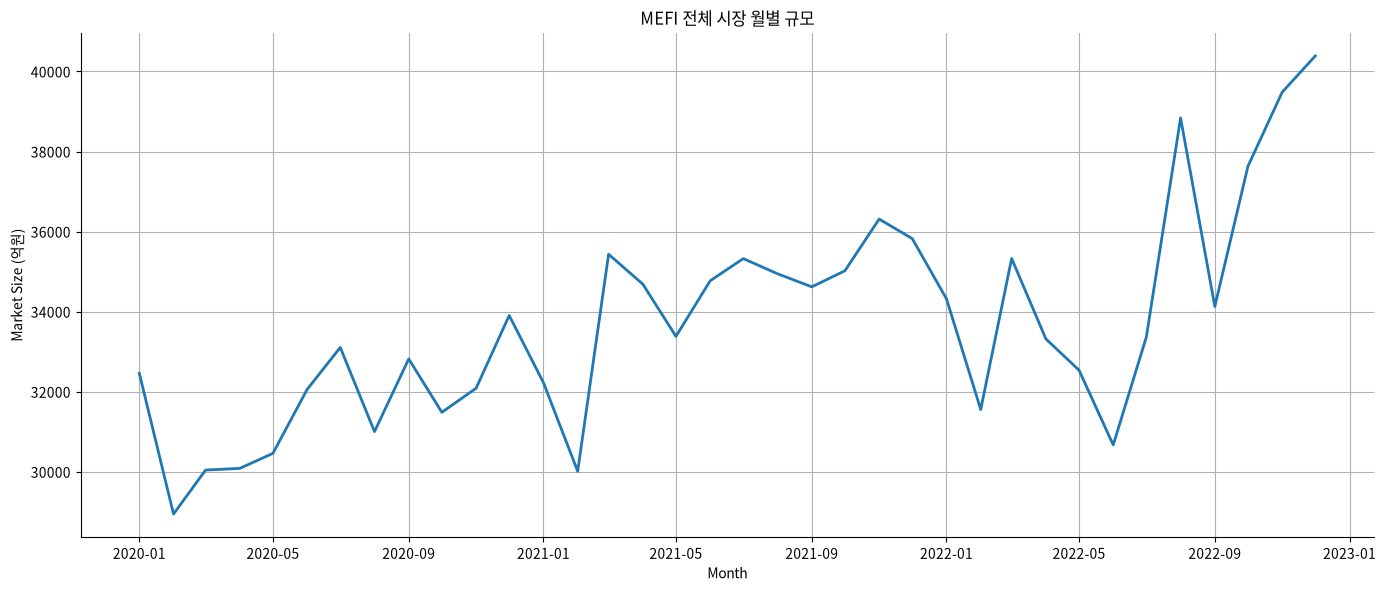

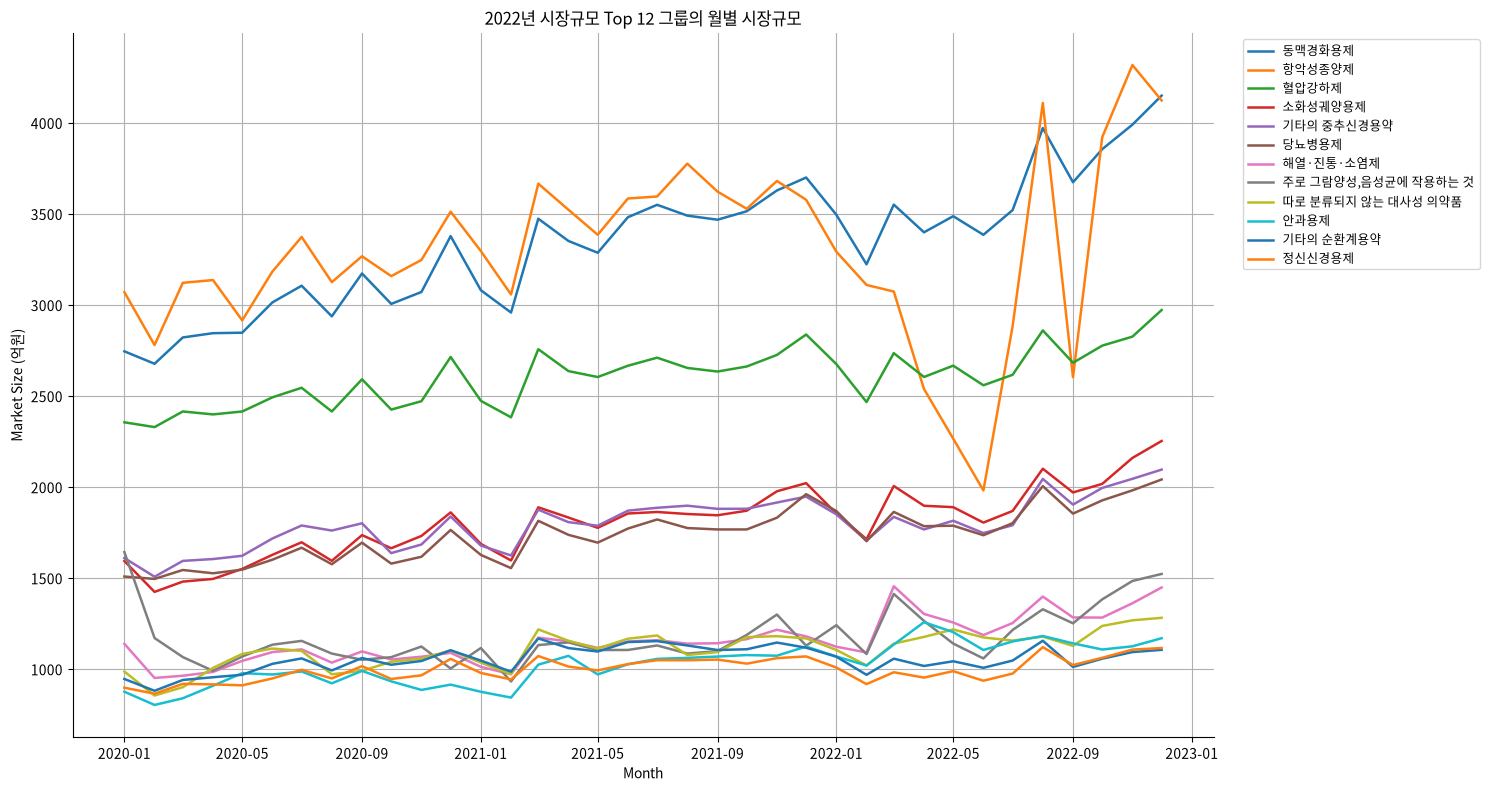

구조적 Trend 결과:


,group_id,group_name,trend_beta,trend_growth,trend_r2,trend_tstat,trend_pvalue,rlm_outlier_n,rlm_outlier_rate
0,111,전신마취제,-0.000700,-0.008366,0.786458,-0.543617,5.919358e-01,0.0,0.000000
1,112,최면진정제,0.001582,0.019167,0.837495,3.088781,5.183507e-03,0.0,0.000000
2,113,항전간제,0.000606,0.007296,0.741054,0.606762,5.499522e-01,2.0,0.055556
3,114,해열·진통·소염제,0.009595,0.122029,0.905680,10.513872,2.945353e-10,2.0,0.055556
4,115,"각성제,흥분제",0.022185,0.305026,0.982202,28.232347,2.358559e-19,2.0,0.055556


2022 시장규모 중앙값: 756.7 억원
Trend Growth 중앙값: 1.27%


/tmp/ipykernel_2940/3672535895.py:1117: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Noto Sans CJK JP.
  plt.tight_layout()
/home/codespace/.local/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Noto Sans CJK JP.
  fig.canvas.print_figure(bytes_io, **kw)


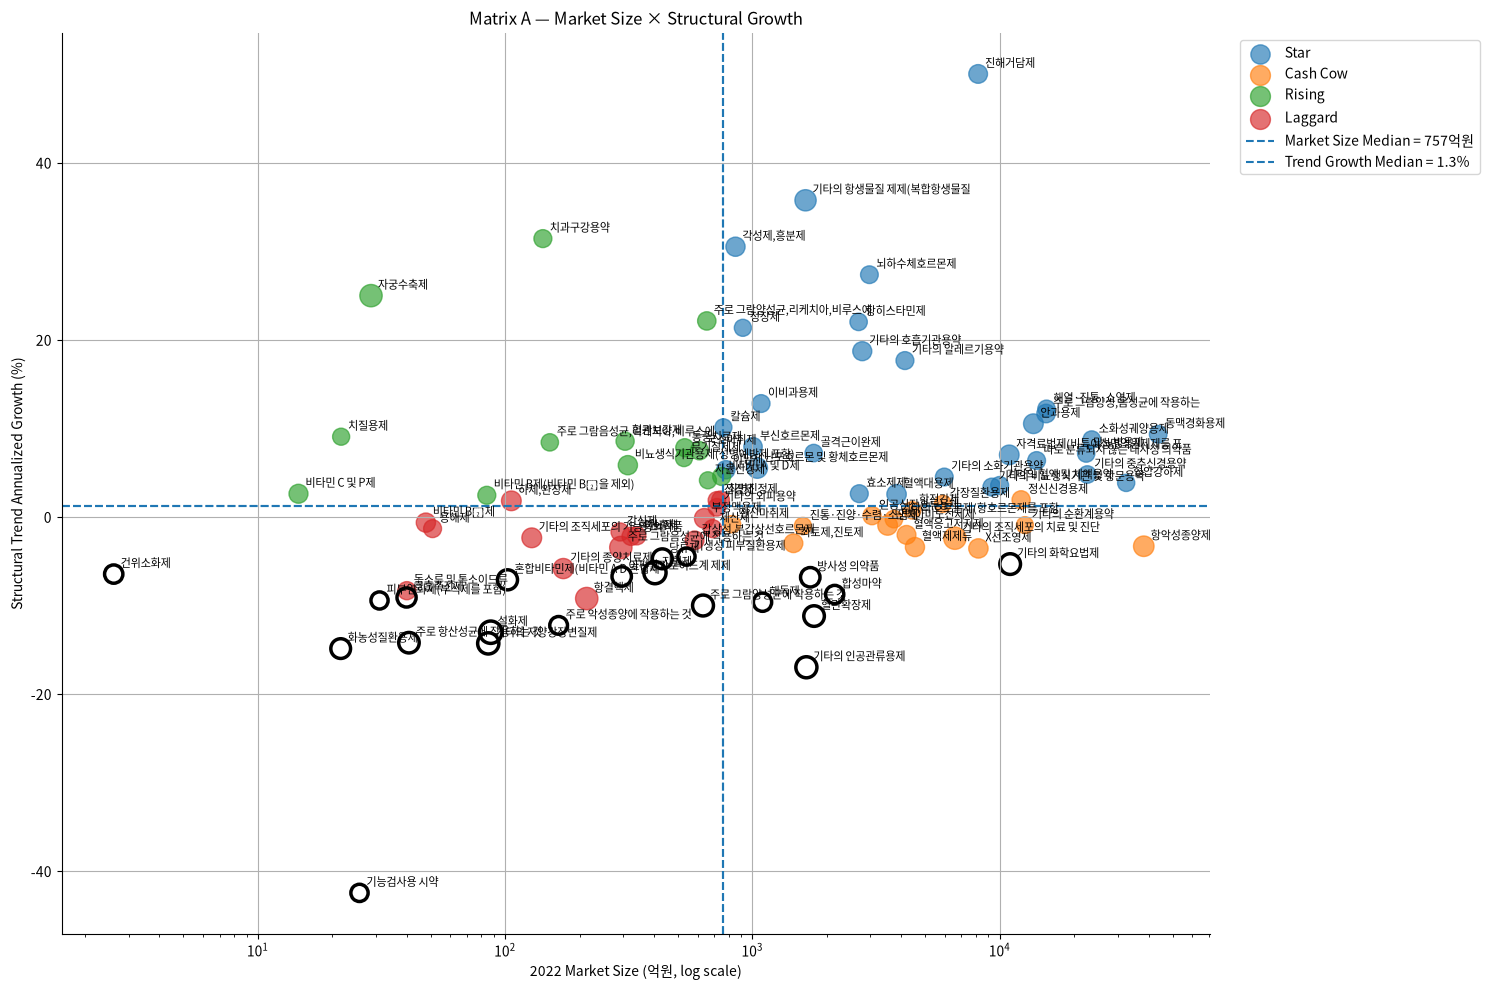

,segment,group_count,market_size_2022_억원,growth_amount_억원,declining_count,group_share_pct,market_share_pct
0,Cash Cow,21,130490.629821,-509.804370,6,21.0,30.953264
1,Laggard,36,9709.049749,-464.693705,15,36.0,2.303053
2,Rising,14,4797.346815,703.473240,0,14.0,1.137963
3,Star,29,276576.056925,42702.546338,0,29.0,65.605720


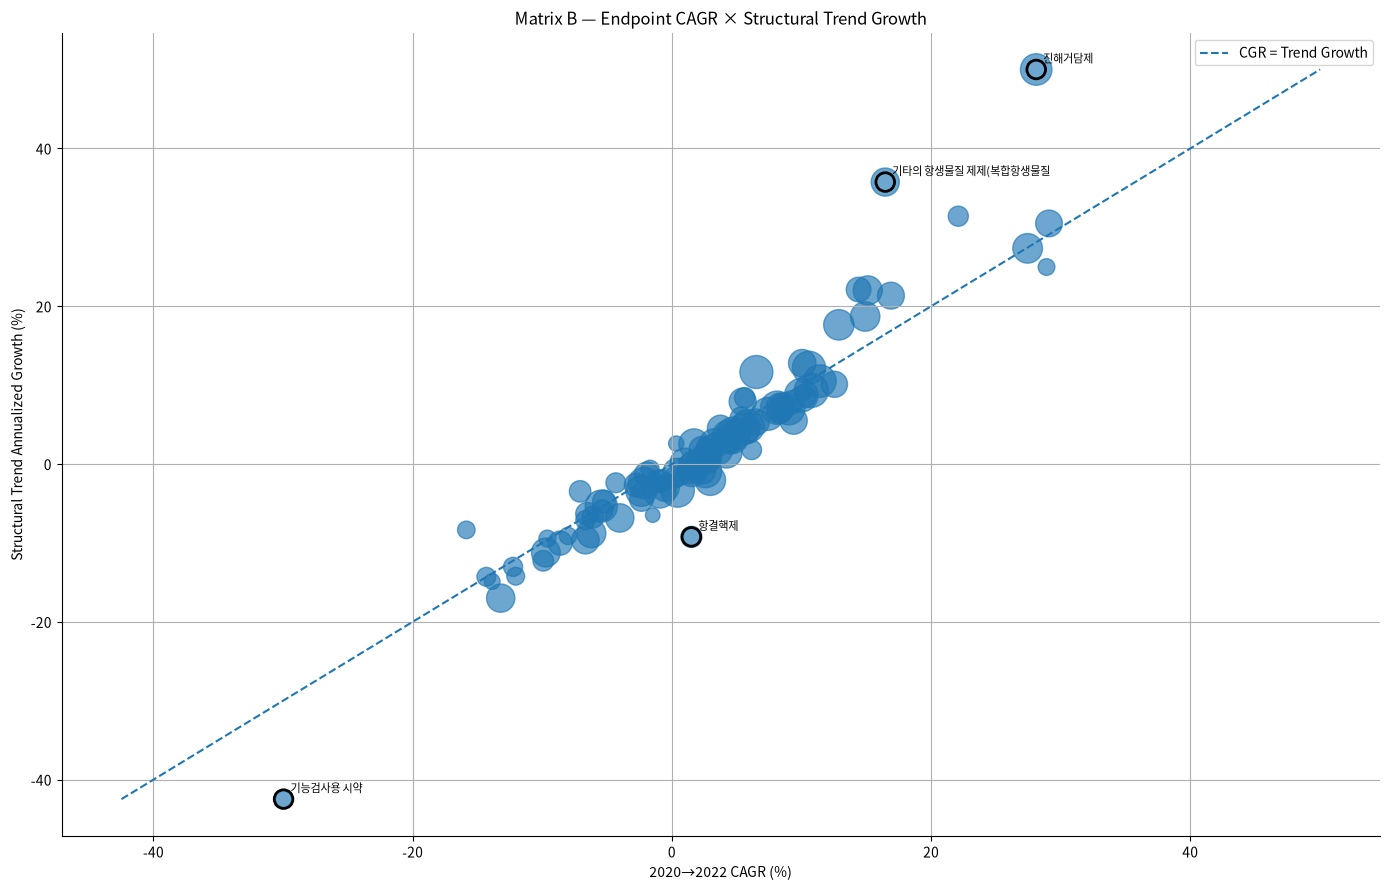

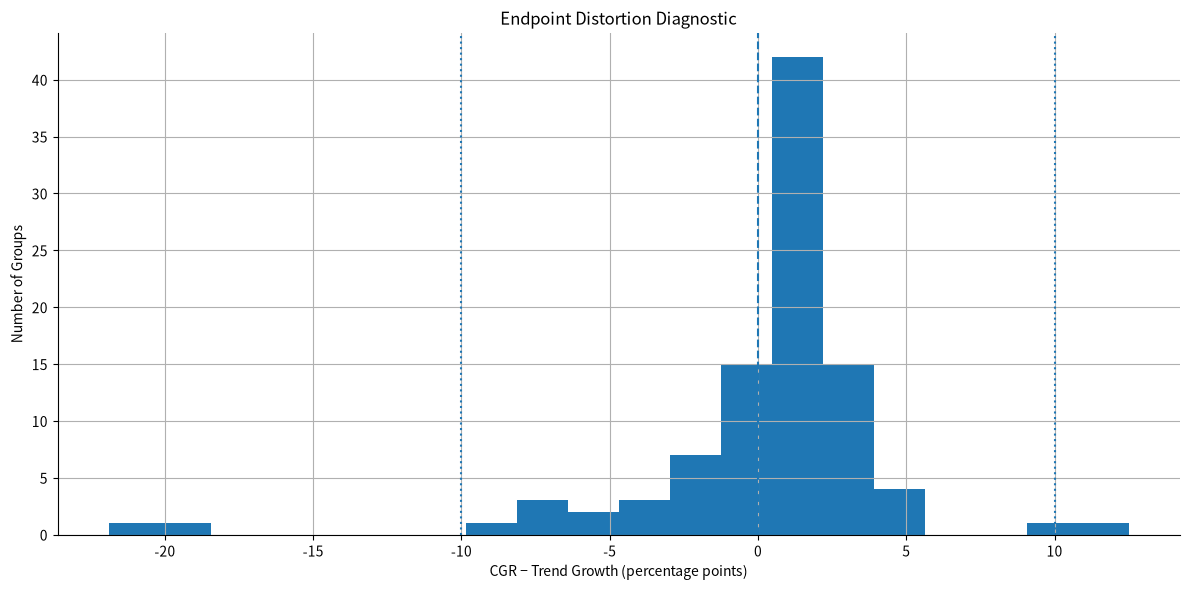

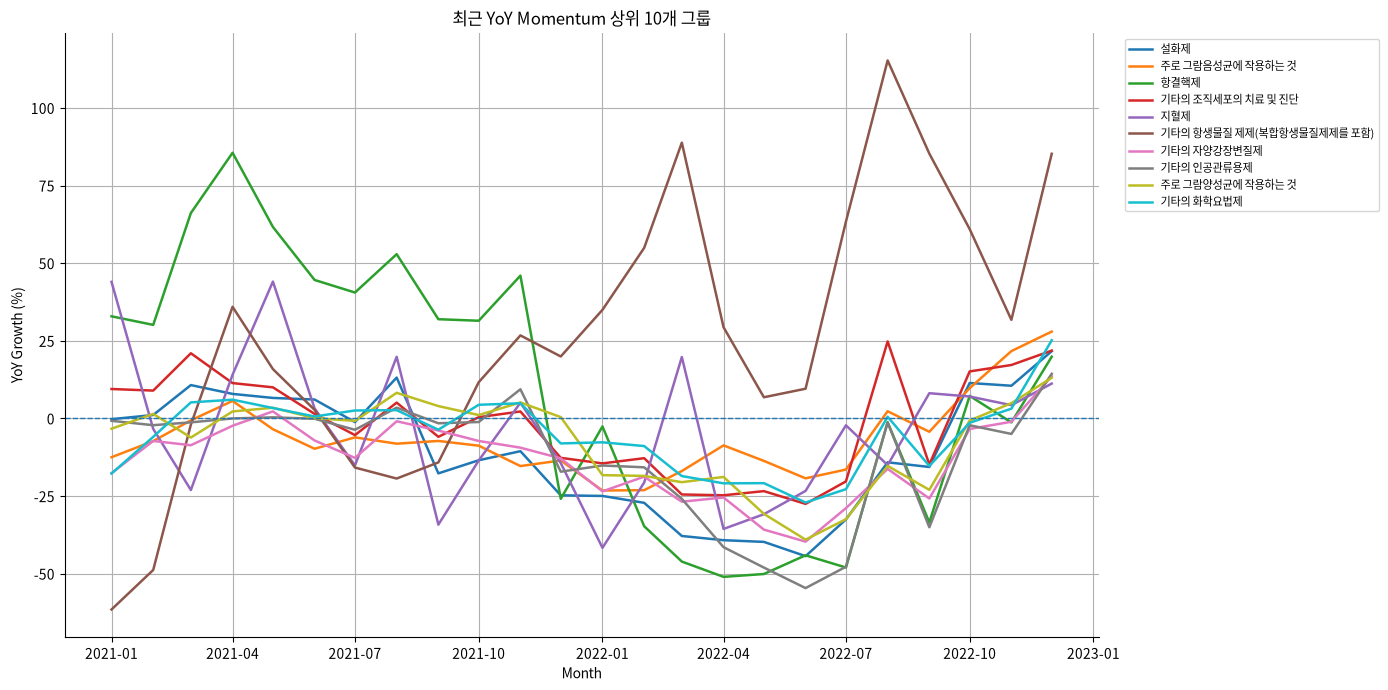

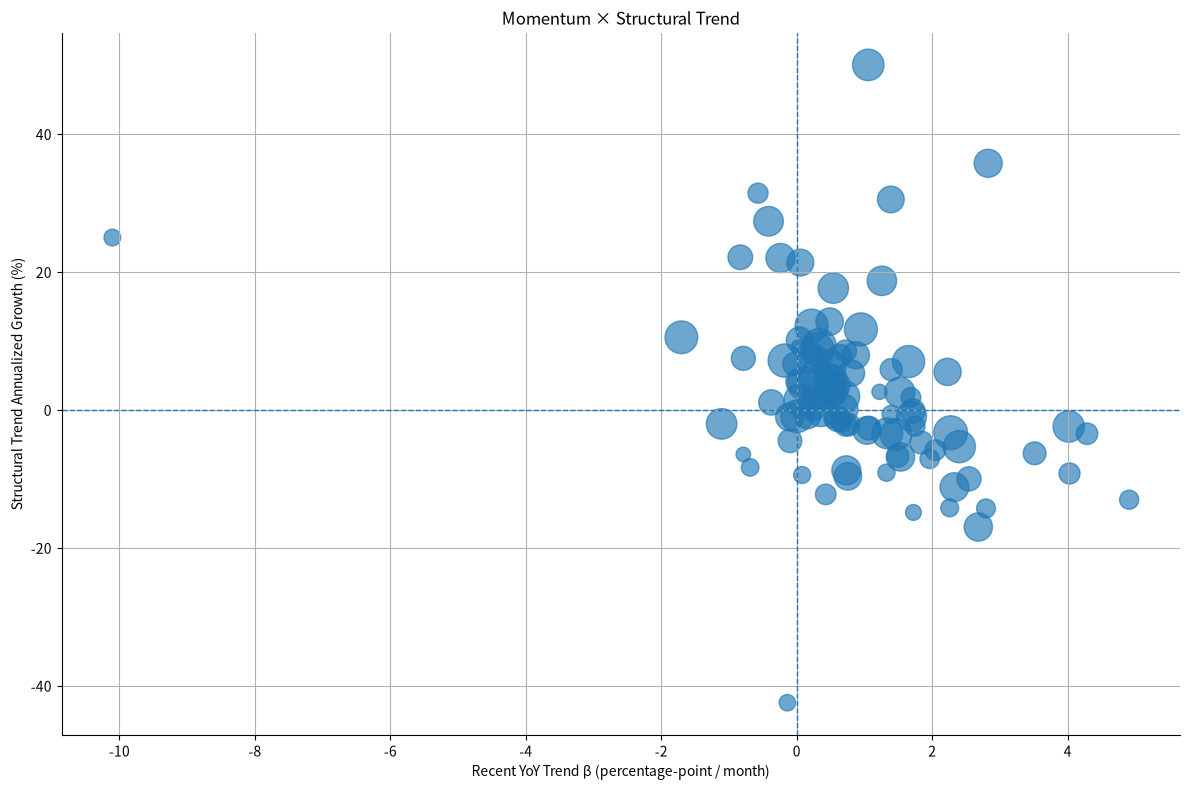

,group_id,group_name,market_size_2022_억원,growth_amount_억원,cgr_pct,trend_growth_pct,trend_r2,trend_tstat,trend_pvalue,cgr_trend_gap_pp,reliability_flag,mean_yoy_growth_pct,yoy_growth_sd_pct,yoy_beta_recent_pct_point_per_month,yoy_beta_recent_tstat,yoy_beta_recent_pvalue,yoy_slope_change,yoy_slope_change_pvalue,is_declining,decline_severity,segment,star_decline_flag,cashcow_recovery_flag,rising_low_reliability_flag,laggard_recovery_flag,anomaly_flag
0,218,동맥경화용제,43708.943014,8081.139566,10.761959,9.322822,0.918471,9.764375,1.196496e-09,1.439137,Reliable,10.903282,6.485034,0.330910,0.689505,0.506190,0.004624,4.519920e-01,False,<NA>,Star,False,False,False,False,False
1,421,항악성종양제,38225.768634,327.727420,0.431450,-3.323106,0.742916,-0.837642,4.108521e-01,3.754556,Reliable,1.052709,18.615243,2.271681,1.325283,0.214558,0.025138,1.708746e-01,False,<NA>,Cash Cow,False,True,False,False,True
2,214,혈압강하제,32447.510443,2871.725418,4.742407,3.828047,0.877624,5.587722,1.098945e-05,0.914360,Reliable,4.819535,4.561809,0.109953,0.317891,0.757106,0.001093,8.189107e-01,False,<NA>,Star,False,False,False,False,False
3,232,소화성궤양용제,23542.230959,4079.244970,9.981357,8.719191,0.934531,10.334796,4.092032e-10,1.262166,Reliable,10.152179,6.454393,0.303404,0.787036,0.449511,0.007870,2.446612e-01,False,<NA>,Star,False,False,False,False,False
4,119,기타의 중추신경용약,22603.762995,2429.713525,5.850724,4.778687,0.861403,5.023922,4.395842e-05,1.072037,Reliable,5.988447,6.028611,0.285001,0.597645,0.563365,0.002818,6.504684e-01,False,<NA>,Star,False,False,False,False,False
5,396,당뇨병용제,22360.662127,3233.549136,8.122883,7.142414,0.901198,8.870251,6.977307e-09,0.980470,Reliable,8.216115,5.034398,-0.177381,-0.393893,0.701928,-0.003184,5.773456e-01,False,<NA>,Star,False,False,False,False,False
6,114,해열·진통·소염제,15451.916260,2814.704691,10.577189,12.202881,0.905680,10.513872,2.945353e-10,-1.625692,Reliable,10.719169,7.795887,0.218876,0.396615,0.699983,-0.004284,6.342427e-01,False,<NA>,Star,False,False,False,False,False
7,618,"주로 그람양성,음성균에 작용하는 것",15393.822269,1827.613601,6.523147,11.667213,0.806194,5.590647,1.091140e-05,-5.144066,Reliable,7.624403,13.960569,0.946825,1.123959,0.287287,-0.018006,1.645177e-01,False,<NA>,Star,False,False,False,False,False
8,399,따로 분류되지 않는 대사성 의약품,14092.137745,1875.757529,7.403187,6.354255,0.888972,7.497780,1.280710e-07,1.048932,Reliable,7.722233,7.739547,0.485590,1.177494,0.266262,0.010356,2.274816e-01,False,<NA>,Star,False,False,False,False,False
9,131,안과용제,13675.771927,2658.998337,11.416295,10.512864,0.877178,10.199417,5.260026e-10,0.903431,Reliable,11.708645,7.797544,-1.703724,-4.669491,0.000881,-0.029266,7.203016e-04,False,<NA>,Star,False,False,False,False,False


,segment,group_count,share_pct
1,Laggard,36,36.0
3,Star,29,29.0
0,Cash Cow,21,21.0
2,Rising,14,14.0


통계적으로 유의한 절대 하락 그룹 수: 21


,group_id,group_name,market_size_2022_억원,growth_amount_억원,cgr_pct,trend_growth_pct,trend_tstat,trend_r2,decline_severity,segment,yoy_beta_recent_pct_point_per_month
0,728,기능검사용 시약,25.756223,-26.750728,-29.962169,-42.472376,-9.046852,0.815392,1,Laggard,-0.138571
1,349,기타의 인공관류용제,1652.010550,-541.099080,-13.208691,-16.991653,-3.751835,0.732307,2,Cash Cow,2.680602
2,263,화농성질환용제,21.619439,-7.522905,-13.868904,-14.881924,-6.341032,0.727662,3,Laggard,1.722497
3,329,기타의 자양강장변질제,85.421086,-30.923758,-14.314177,-14.293495,-5.001065,0.695454,4,Laggard,2.793903
4,613,주로 항산성균에 작용하는 것,40.816299,-11.949871,-12.049356,-14.217072,-5.250381,0.761330,5,Laggard,2.258235
5,621,설화제,87.406605,-26.117184,-12.253725,-13.032656,-3.363707,0.596791,6,Laggard,4.907686
6,617,주로 악성종양에 작용하는 것,164.491249,-38.235976,-9.922700,-12.260576,-5.465341,0.750669,7,Laggard,0.427685
7,217,혈관확장제,1774.452366,-402.816877,-9.723211,-11.207826,-5.393157,0.664930,8,Cash Cow,2.328007
8,611,주로 그람양성균에 작용하는 것,630.984015,-124.692844,-8.622112,-10.018096,-3.266588,0.704926,9,Laggard,2.541906
9,392,해독제,1098.160667,-162.539213,-6.668749,-9.644134,-4.218289,0.731786,10,Cash Cow,0.753572


,group_id,group_name,segment,market_size_2022_억원,growth_amount_억원,cgr_pct,trend_growth_pct,trend_r2,trend_tstat,reliability_flag,yoy_beta_recent_pct_point_per_month,is_declining,star_decline_flag,cashcow_recovery_flag,rising_low_reliability_flag,laggard_recovery_flag
0,721,X선조영제,Cash Cow,8196.724393,-153.977906,-0.926235,-3.569771,0.693696,-1.739716,Reliable,1.465587,False,False,True,False,False
1,391,간장질환용제,Cash Cow,5890.508220,466.764174,4.214174,1.461031,0.777151,1.236236,Reliable,0.040269,False,False,True,False,False
2,219,기타의 순환계용약,Cash Cow,12641.718558,628.064606,2.580663,-0.938351,0.587213,-0.813398,Reliable,0.003978,False,False,True,False,False
3,349,기타의 인공관류용제,Cash Cow,1652.010550,-541.099080,-13.208691,-16.991653,0.732307,-3.751835,Reliable,2.680602,True,False,True,False,False
4,439,기타의 조직세포의 치료 및 진단,Cash Cow,6584.700966,-295.016867,-2.167598,-2.415368,0.691224,-0.740612,Reliable,4.015262,False,False,True,False,False
5,249,기타의 호르몬제(항호르몬제를 포함),Cash Cow,3732.085690,121.604486,1.670102,-0.259155,0.697428,-0.202369,Reliable,0.357678,False,False,True,False,False
6,629,기타의 화학요법제,Cash Cow,11015.464690,-1305.740733,-5.447109,-5.338289,0.709141,-2.094385,Reliable,2.399929,True,False,True,False,False
7,325,단백아미노산제제,Cash Cow,3519.998010,106.413356,1.546713,-0.967527,0.707715,-0.418482,Reliable,1.693956,False,False,True,False,False
8,431,방사성 의약품,Cash Cow,1712.811169,-146.644459,-4.024180,-6.828053,0.722571,-2.403162,Reliable,1.530554,True,False,True,False,False
9,341,인공신장관류용제,Cash Cow,3044.872979,60.217658,1.003750,0.126669,0.743888,0.120457,Reliable,0.684362,False,False,True,False,False


,segment,total_groups,declining_groups,endpoint_warning_groups,anomaly_groups,declining_share_pct,anomaly_share_pct
0,Cash Cow,21,6,0,19,28.571429,90.47619
1,Laggard,36,15,2,27,41.666667,75.00000
2,Rising,14,0,0,0,0.000000,0.00000
3,Star,29,0,2,0,0.000000,0.00000


,group_id,group_name,market_size_2022_억원,growth_amount_억원,cgr_pct,trend_growth_pct,trend_r2,trend_tstat,cgr_trend_gap_pp,reliability_flag,mean_yoy_growth_pct,yoy_growth_sd_pct,yoy_beta_recent_pct_point_per_month,is_declining,decline_severity,segment,anomaly_flag
0,218,동맥경화용제,43708.943014,8081.139566,10.761959,9.322822,0.918471,9.764375,1.439137,Reliable,10.903282,6.485034,0.330910,False,<NA>,Star,False
1,421,항악성종양제,38225.768634,327.727420,0.431450,-3.323106,0.742916,-0.837642,3.754556,Reliable,1.052709,18.615243,2.271681,False,<NA>,Cash Cow,True
2,214,혈압강하제,32447.510443,2871.725418,4.742407,3.828047,0.877624,5.587722,0.914360,Reliable,4.819535,4.561809,0.109953,False,<NA>,Star,False
3,232,소화성궤양용제,23542.230959,4079.244970,9.981357,8.719191,0.934531,10.334796,1.262166,Reliable,10.152179,6.454393,0.303404,False,<NA>,Star,False
4,119,기타의 중추신경용약,22603.762995,2429.713525,5.850724,4.778687,0.861403,5.023922,1.072037,Reliable,5.988447,6.028611,0.285001,False,<NA>,Star,False
5,396,당뇨병용제,22360.662127,3233.549136,8.122883,7.142414,0.901198,8.870251,0.980470,Reliable,8.216115,5.034398,-0.177381,False,<NA>,Star,False
6,114,해열·진통·소염제,15451.916260,2814.704691,10.577189,12.202881,0.905680,10.513872,-1.625692,Reliable,10.719169,7.795887,0.218876,False,<NA>,Star,False
7,618,"주로 그람양성,음성균에 작용하는 것",15393.822269,1827.613601,6.523147,11.667213,0.806194,5.590647,-5.144066,Reliable,7.624403,13.960569,0.946825,False,<NA>,Star,False
8,399,따로 분류되지 않는 대사성 의약품,14092.137745,1875.757529,7.403187,6.354255,0.888972,7.497780,1.048932,Reliable,7.722233,7.739547,0.485590,False,<NA>,Star,False
9,131,안과용제,13675.771927,2658.998337,11.416295,10.512864,0.877178,10.199417,0.903431,Reliable,11.708645,7.797544,-1.703724,False,<NA>,Star,False


In [5]:
# ============================================================
# MEFI_SICK 전체 시장구조 분석 Pipeline
# ============================================================
# ① 월별 시장규모
# ② 구조적 추세: log(사용액) ~ time + month dummies, WLS
# ③ 2020→2022 성장 결과 + 신뢰도
# ④ Rolling YoY / Momentum
# ⑤ Absolute Decline Flag
# ⑥ Matrix A: 규모 × 구조적 성장
# ⑦ Matrix B: CGR × Trend Growth
# ⑧ 전체 Diagnostic Table
#
# 원칙
# - 분류: Robust Z-score
# - 시각화: 원본 단위
# - 파일 저장 없음
# - Jupyter에서 바로 출력
# ============================================================


# ============================================================
# 0. Libraries
# ============================================================

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import statsmodels.api as sm
import statsmodels.formula.api as smf

from scipy import stats

from IPython.display import display


# ------------------------------------------------------------
# Plot 기본 설정
# ------------------------------------------------------------

plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)


# ============================================================
# 1. DuckDB connection
# ============================================================

# 이미 con이 존재한다면 이 부분은 그대로 실행해도 됩니다.
# 기존 con을 사용하고 싶다면 아래 줄은 생략 가능

try:
    con
except NameError:
    con = duckdb.connect()


# ============================================================
# 2. 분석 기간 / 주요 변수 설정
# ============================================================

START_YEAR = 2020
END_YEAR = 2022

ANALYSIS_MONTHS = 36

# WLS recency weight
RECENCY_DECAY = 0.90

# robust z-score의 MAD 보정계수
MAD_SCALE = 1.4826

# endpoint distortion flag
# CGR과 Trend Growth의 차이가 10%p 이상이면 경고
GAP_THRESHOLD_PP = 10

# robust gap z-score threshold
GAP_Z_THRESHOLD = 3

# Absolute decline
DECLINE_TSTAT_THRESHOLD = 2


# ============================================================
# 3. MEFI_SICK 월별 시장규모 생성
# ============================================================

monthly = con.execute(f"""
    SELECT
        CAST(meftDivNo AS VARCHAR) AS group_id,
        meftDivNoNm AS group_name,

        CAST(
            SUBSTR(CAST(diagYm AS VARCHAR), 1, 4)
            AS INTEGER
        ) AS year,

        CAST(
            SUBSTR(CAST(diagYm AS VARCHAR), 5, 2)
            AS INTEGER
        ) AS month,

        SUM(msupUseAmt) AS market_amt

    FROM mefi_sick

    WHERE
        CAST(SUBSTR(CAST(diagYm AS VARCHAR), 1, 4) AS INTEGER)
        BETWEEN {START_YEAR} AND {END_YEAR}

    GROUP BY
        group_id,
        group_name,
        year,
        month

    ORDER BY
        group_id,
        year,
        month
""").df()


# ============================================================
# 4. 날짜 / log 시장규모
# ============================================================

monthly["date"] = pd.to_datetime(
    monthly["year"].astype(str)
    + "-"
    + monthly["month"].astype(str).str.zfill(2)
    + "-01"
)

monthly = monthly.sort_values(
    ["group_id", "date"]
).reset_index(drop=True)


# 시장규모가 0 이하인 경우 log 불가
monthly["market_amt"] = monthly["market_amt"].astype(float)

monthly["log_market_amt"] = np.where(
    monthly["market_amt"] > 0,
    np.log(monthly["market_amt"]),
    np.nan
)


# 전체시장 월별 규모
overall_monthly = (
    monthly
    .groupby(["date", "year", "month"], as_index=False)
    ["market_amt"]
    .sum()
)

overall_monthly["market_amt_억원"] = (
    overall_monthly["market_amt"] / 1e8
)


print("월별 데이터:")
display(monthly.head())

print("\n그룹 수:", monthly["group_id"].nunique())
print("월 수:", monthly["date"].nunique())


# ============================================================
# 5. ① 월별 전체 시장규모 시계열
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    overall_monthly["date"],
    overall_monthly["market_amt_억원"],
    linewidth=2
)

plt.title("MEFI 전체 시장 월별 규모")
plt.xlabel("Month")
plt.ylabel("Market Size (억원)")

plt.tight_layout()
plt.show()


# ============================================================
# 6. ① 그룹별 월별 시장규모
# ============================================================

# 2022년 시장규모 상위 12개 그룹
group_2022_size = (
    monthly[monthly["year"] == END_YEAR]
    .groupby(["group_id", "group_name"], as_index=False)
    ["market_amt"]
    .sum()
    .sort_values("market_amt", ascending=False)
)

TOP_N_GROUPS = 12

top_groups = group_2022_size.head(TOP_N_GROUPS)["group_id"].tolist()


plt.figure(figsize=(15, 8))

for gid in top_groups:

    temp = monthly[
        monthly["group_id"] == gid
    ]

    name = temp["group_name"].iloc[0]

    plt.plot(
        temp["date"],
        temp["market_amt"] / 1e8,
        linewidth=1.8,
        label=name
    )

plt.title(f"2022년 시장규모 Top {TOP_N_GROUPS} 그룹의 월별 시장규모")
plt.xlabel("Month")
plt.ylabel("Market Size (억원)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

plt.tight_layout()
plt.show()


# ============================================================
# 7. Robust Z-score 함수
# ============================================================

def robust_zscore(series):
    """
    Median + MAD 기반 robust z-score

    z = (x - median) / (1.4826 * MAD)

    중앙값을 0 기준으로 사용하므로
    z >= 0 = median 이상
    z < 0  = median 미만
    """

    s = pd.Series(series).astype(float)

    median = s.median()

    mad = np.median(
        np.abs(s - median)
    )

    scale = MAD_SCALE * mad

    if scale == 0 or np.isnan(scale):

        # MAD가 0이면 fallback
        std = s.std()

        if std == 0 or np.isnan(std):
            return pd.Series(
                np.zeros(len(s)),
                index=s.index
            )

        return (s - s.mean()) / std

    return (s - median) / scale


# ============================================================
# 8. ② 구조적 추세 함수
# ============================================================

def fit_structural_trend(group_df):

    d = group_df.copy()

    d = d.sort_values("date").reset_index(drop=True)

    # 최소 관측치
    d = d[
        d["log_market_amt"].notna()
    ].copy()

    if len(d) < 24:
        return pd.Series({
            "trend_beta": np.nan,
            "trend_growth": np.nan,
            "trend_r2": np.nan,
            "trend_tstat": np.nan,
            "trend_pvalue": np.nan,
            "rlm_outlier_n": np.nan,
            "rlm_outlier_rate": np.nan,
        })

    # ----------------------------------------
    # Time index
    # ----------------------------------------

    d["time"] = np.arange(len(d))

    # 최근 데이터에 더 높은 weight
    max_time = d["time"].max()

    d["age"] = max_time - d["time"]

    d["weight"] = RECENCY_DECAY ** d["age"]

    # ----------------------------------------
    # Month dummy
    # ----------------------------------------

    month_dummies = pd.get_dummies(
        d["month"].astype(str),
        prefix="month",
        drop_first=True,
        dtype=float
    )

    X = pd.concat(
        [
            d[["time"]],
            month_dummies
        ],
        axis=1
    )

    X = sm.add_constant(
        X,
        has_constant="add"
    )

    y = d["log_market_amt"].astype(float)

    # ----------------------------------------
    # WLS
    # ----------------------------------------

    model = sm.WLS(
        y,
        X,
        weights=d["weight"]
    ).fit()

    beta = model.params["time"]

    annualized_growth = (
        np.exp(beta * 12) - 1
    )

    # ----------------------------------------
    # RLM robust regression
    # ----------------------------------------

    try:

        rlm_model = sm.RLM(
            y,
            X,
            M=sm.robust.norms.HuberT()
        ).fit()

        resid = rlm_model.resid

        median_resid = np.median(resid)

        mad_resid = np.median(
            np.abs(resid - median_resid)
        )

        if mad_resid > 0:

            robust_resid_z = (
                resid - median_resid
            ) / (
                MAD_SCALE * mad_resid
            )

            outlier_mask = (
                np.abs(robust_resid_z) >= 3
            )

            outlier_n = int(
                outlier_mask.sum()
            )

        else:

            outlier_n = 0

    except Exception:

        outlier_n = np.nan

    return pd.Series({

        "trend_beta": beta,

        "trend_growth":
            annualized_growth,

        "trend_r2":
            model.rsquared,

        "trend_tstat":
            model.tvalues["time"],

        "trend_pvalue":
            model.pvalues["time"],

        "rlm_outlier_n":
            outlier_n,

        "rlm_outlier_rate":
            outlier_n / len(d)
            if pd.notna(outlier_n)
            else np.nan
    })


# ============================================================
# 9. 전체 그룹 구조적 Trend 계산
# ============================================================

trend_results = (
    monthly
    .groupby(
        ["group_id", "group_name"],
        group_keys=False
    )
    .apply(fit_structural_trend)
    .reset_index()
)

print("구조적 Trend 결과:")
display(trend_results.head())


# ============================================================
# 10. ③ 2020 → 2022 시장규모 / 성장액 / CGR
# ============================================================

annual_market = (
    monthly
    .groupby(
        ["group_id", "group_name", "year"],
        as_index=False
    )
    ["market_amt"]
    .sum()
)

annual_pivot = (
    annual_market
    .pivot_table(
        index=["group_id", "group_name"],
        columns="year",
        values="market_amt",
        aggfunc="sum"
    )
    .reset_index()
)

annual_pivot.columns.name = None


# 컬럼 안전하게 생성
if START_YEAR not in annual_pivot.columns:
    annual_pivot[START_YEAR] = np.nan

if END_YEAR not in annual_pivot.columns:
    annual_pivot[END_YEAR] = np.nan


annual_pivot = annual_pivot.rename(
    columns={
        START_YEAR: "market_2020",
        END_YEAR: "market_2022"
    }
)


# 성장액
annual_pivot["growth_amount"] = (
    annual_pivot["market_2022"]
    - annual_pivot["market_2020"]
)


annual_pivot["growth_amount_억원"] = (
    annual_pivot["growth_amount"] / 1e8
)


# CAGR
annual_pivot["cgr"] = np.where(
    (
        annual_pivot["market_2020"] > 0
    )
    &
    (
        annual_pivot["market_2022"] > 0
    ),
    (
        annual_pivot["market_2022"]
        /
        annual_pivot["market_2020"]
    ) ** (1 / 2) - 1,
    np.nan
)


annual_pivot["cgr_pct"] = (
    annual_pivot["cgr"] * 100
)


# ============================================================
# 11. Trend + Growth 결과 통합
# ============================================================

diagnostic = (
    annual_pivot
    .merge(
        trend_results,
        on=["group_id", "group_name"],
        how="left"
    )
)


diagnostic["trend_growth_pct"] = (
    diagnostic["trend_growth"] * 100
)


# ============================================================
# 12. ③ CGR vs Trend Growth gap
# ============================================================

diagnostic["cgr_trend_gap"] = (
    diagnostic["cgr"]
    -
    diagnostic["trend_growth"]
)

diagnostic["cgr_trend_gap_pp"] = (
    diagnostic["cgr_trend_gap"] * 100
)


# gap robust z
diagnostic["gap_robust_z"] = robust_zscore(
    diagnostic["cgr_trend_gap"]
)


diagnostic["endpoint_distortion_flag"] = np.where(
    (
        diagnostic["cgr_trend_gap_pp"].abs()
        >= GAP_THRESHOLD_PP
    )
    |
    (
        diagnostic["gap_robust_z"].abs()
        >= GAP_Z_THRESHOLD
    ),
    True,
    False
)


# 방향까지 표시
def reliability_label(row):

    if not row["endpoint_distortion_flag"]:
        return "Reliable"

    gap = row["cgr_trend_gap_pp"]

    if gap > 0:
        return "Endpoint > Trend"

    return "Endpoint < Trend"


diagnostic["reliability_flag"] = diagnostic.apply(
    reliability_label,
    axis=1
)


# ============================================================
# 13. ④ Monthly YoY
# ============================================================

monthly = monthly.sort_values(
    ["group_id", "date"]
).copy()


monthly["yoy_growth"] = (
    monthly
    .groupby("group_id")["market_amt"]
    .pct_change(periods=12)
)


# ============================================================
# 14. YoY Momentum 함수
# ============================================================

def calc_yoy_momentum(group_df):

    d = group_df.copy()

    d = d[
        d["yoy_growth"].notna()
    ].sort_values("date")

    if len(d) < 12:

        return pd.Series({

            "mean_yoy_growth": np.nan,
            "yoy_growth_sd": np.nan,
            "yoy_beta_recent": np.nan,
            "yoy_beta_recent_tstat": np.nan,
            "yoy_beta_recent_pvalue": np.nan,
            "yoy_slope_change": np.nan,
            "yoy_slope_change_pvalue": np.nan
        })

    # --------------------------------------------------------
    # Mean / SD
    # --------------------------------------------------------

    mean_yoy = d["yoy_growth"].mean()

    sd_yoy = d["yoy_growth"].std()

    # --------------------------------------------------------
    # 최근 12개월 YoY trend
    # --------------------------------------------------------

    recent = d.tail(12).copy()

    recent["t_recent"] = np.arange(
        len(recent)
    )

    X_recent = sm.add_constant(
        recent["t_recent"]
    )

    recent_model = sm.OLS(
        recent["yoy_growth"],
        X_recent
    ).fit()

    yoy_beta_recent = (
        recent_model.params["t_recent"]
    )

    yoy_tstat = (
        recent_model.tvalues["t_recent"]
    )

    yoy_pvalue = (
        recent_model.pvalues["t_recent"]
    )

    # --------------------------------------------------------
    # 초기 12개월 vs 최근 12개월
    # slope difference test
    # --------------------------------------------------------

    if len(d) >= 24:

        d24 = d.tail(24).copy()

        d24["t"] = np.arange(
            len(d24)
        )

        d24["late"] = (
            d24["t"] >= 12
        ).astype(int)

        d24["t_late"] = (
            d24["t"]
            *
            d24["late"]
        )

        X_change = sm.add_constant(
            d24[
                ["t", "late", "t_late"]
            ]
        )

        change_model = sm.OLS(
            d24["yoy_growth"],
            X_change
        ).fit()

        slope_change = (
            change_model.params["t_late"]
        )

        slope_change_pvalue = (
            change_model.pvalues["t_late"]
        )

    else:

        slope_change = np.nan
        slope_change_pvalue = np.nan

    return pd.Series({

        "mean_yoy_growth":
            mean_yoy,

        "yoy_growth_sd":
            sd_yoy,

        "yoy_beta_recent":
            yoy_beta_recent,

        "yoy_beta_recent_tstat":
            yoy_tstat,

        "yoy_beta_recent_pvalue":
            yoy_pvalue,

        "yoy_slope_change":
            slope_change,

        "yoy_slope_change_pvalue":
            slope_change_pvalue
    })


# ============================================================
# 15. Momentum 계산
# ============================================================

momentum_results = (
    monthly
    .groupby(
        ["group_id", "group_name"],
        group_keys=False
    )
    .apply(calc_yoy_momentum)
    .reset_index()
)


diagnostic = diagnostic.merge(
    momentum_results,
    on=["group_id", "group_name"],
    how="left"
)


diagnostic["mean_yoy_growth_pct"] = (
    diagnostic["mean_yoy_growth"] * 100
)

diagnostic["yoy_growth_sd_pct"] = (
    diagnostic["yoy_growth_sd"] * 100
)

diagnostic["yoy_beta_recent_pct_point_per_month"] = (
    diagnostic["yoy_beta_recent"] * 100
)


# ============================================================
# 16. ⑤ Absolute Decline Flag
# ============================================================

diagnostic["is_declining"] = (
    (diagnostic["trend_growth"] < 0)
    &
    (diagnostic["trend_tstat"].abs() >= DECLINE_TSTAT_THRESHOLD)
)


# ============================================================
# 17. decline severity
# ============================================================

declining = diagnostic[
    diagnostic["is_declining"]
].copy()


# 가장 가파른 하락 = 1위
declining["decline_severity"] = (
    declining["trend_growth"]
    .rank(
        ascending=True,
        method="min"
    )
)


diagnostic = diagnostic.merge(
    declining[
        [
            "group_id",
            "decline_severity"
        ]
    ],
    on="group_id",
    how="left"
)


diagnostic["decline_severity"] = (
    diagnostic["decline_severity"]
    .astype("Int64")
)


# 하락폭 자체도 표시
diagnostic["decline_rate_pct"] = np.where(
    diagnostic["is_declining"],
    diagnostic["trend_growth_pct"],
    np.nan
)


# ============================================================
# 18. ⑥ Matrix A용 Robust Z-score
# ============================================================

# 2022 시장규모
diagnostic["market_size_2022"] = (
    diagnostic["market_2022"]
)

diagnostic["market_size_2022_억원"] = (
    diagnostic["market_size_2022"]
    / 1e8
)


# X축 분류용
diagnostic["size_log_2022"] = np.where(
    diagnostic["market_size_2022"] > 0,
    np.log(
        diagnostic["market_size_2022"]
    ),
    np.nan
)


diagnostic["size_z"] = robust_zscore(
    diagnostic["size_log_2022"]
)


# Y축 분류용
diagnostic["trend_growth_z"] = robust_zscore(
    diagnostic["trend_growth"]
)


# ============================================================
# 19. Matrix A Segment
# ============================================================

def assign_segment(row):

    size_high = row["size_z"] >= 0
    growth_high = row["trend_growth_z"] >= 0

    if size_high and growth_high:
        return "Star"

    elif size_high and not growth_high:
        return "Cash Cow"

    elif not size_high and growth_high:
        return "Rising"

    else:
        return "Laggard"


diagnostic["segment"] = diagnostic.apply(
    assign_segment,
    axis=1
)


# ============================================================
# 20. Matrix A 기준선
# ============================================================

# robust z = 0
# → median
# → 시각화는 원본 단위

market_size_median_억원 = (
    diagnostic["market_size_2022_억원"]
    .median()
)

trend_growth_median_pct = (
    diagnostic["trend_growth_pct"]
    .median()
)


print(
    f"2022 시장규모 중앙값: "
    f"{market_size_median_억원:,.1f} 억원"
)

print(
    f"Trend Growth 중앙값: "
    f"{trend_growth_median_pct:.2f}%"
)


# ============================================================
# 21. Matrix A Bubble Size
# ============================================================

# YoY beta 절대값을 bubble size로 사용
# 너무 작은 값 방지

diagnostic["bubble_size"] = (
    diagnostic["yoy_beta_recent"]
    .abs()
)

if diagnostic["bubble_size"].notna().any():

    max_bubble = diagnostic[
        "bubble_size"
    ].quantile(0.95)

    diagnostic["bubble_size_plot"] = (
        diagnostic["bubble_size"]
        .clip(upper=max_bubble)
        .fillna(0)
    )

else:

    diagnostic["bubble_size_plot"] = 0


# ============================================================
# 22. ⑥ Matrix A 시각화
# ============================================================

plt.figure(figsize=(15, 10))


segment_order = [
    "Star",
    "Cash Cow",
    "Rising",
    "Laggard"
]


markers = {
    "Star": "o",
    "Cash Cow": "o",
    "Rising": "o",
    "Laggard": "o"
}


for segment in segment_order:

    temp = diagnostic[
        diagnostic["segment"] == segment
    ]

    # 일반 그룹
    normal = temp[
        ~temp["is_declining"]
    ]

    plt.scatter(
        normal["market_size_2022_억원"],
        normal["trend_growth_pct"],
        s=(
            150
            +
            normal["bubble_size_plot"] * 3000
        ),
        alpha=0.65,
        label=segment
    )

    # Absolute Decline 그룹
    decline = temp[
        temp["is_declining"]
    ]

    if len(decline) > 0:

        plt.scatter(
            decline["market_size_2022_억원"],
            decline["trend_growth_pct"],
            s=(
                150
                +
                decline["bubble_size_plot"] * 3000
            ),
            facecolors="none",
            edgecolors="black",
            linewidths=2.5,
            marker="o"
        )


# ------------------------------------------------------------
# Quadrant boundary
# ------------------------------------------------------------

plt.axvline(
    market_size_median_억원,
    linestyle="--",
    linewidth=1.5
)

plt.axhline(
    trend_growth_median_pct,
    linestyle="--",
    linewidth=1.5
)


# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

for _, row in diagnostic.iterrows():

    plt.annotate(
        str(row["group_name"])[:18],
        (
            row["market_size_2022_억원"],
            row["trend_growth_pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )


# ------------------------------------------------------------
# Axis
# ------------------------------------------------------------

plt.xscale("log")

plt.xlabel(
    "2022 Market Size (억원, log scale)"
)

plt.ylabel(
    "Structural Trend Annualized Growth (%)"
)

plt.title(
    "Matrix A — Market Size × Structural Growth"
)

plt.axvline(
    market_size_median_억원,
    linestyle="--",
    linewidth=1.5,
    label=f"Market Size Median = {market_size_median_억원:,.0f}억원"
)

plt.axhline(
    trend_growth_median_pct,
    linestyle="--",
    linewidth=1.5,
    label=f"Trend Growth Median = {trend_growth_median_pct:.1f}%"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


# ============================================================
# 23. Matrix A 사분면별 요약
# ============================================================

segment_summary = (
    diagnostic
    .groupby("segment")
    .agg(
        group_count=("group_id", "nunique"),
        market_size_2022_억원=(
            "market_size_2022_억원",
            "sum"
        ),
        growth_amount_억원=(
            "growth_amount_억원",
            "sum"
        ),
        declining_count=(
            "is_declining",
            "sum"
        )
    )
    .reset_index()
)

segment_summary["group_share_pct"] = (
    segment_summary["group_count"]
    /
    len(diagnostic)
    * 100
)

segment_summary["market_share_pct"] = (
    segment_summary[
        "market_size_2022_억원"
    ]
    /
    segment_summary[
        "market_size_2022_억원"
    ].sum()
    * 100
)

display(
    segment_summary.sort_values(
        "segment"
    )
)


# ============================================================
# 24. ⑦ Matrix B — CGR × Trend Growth
# ============================================================

plt.figure(figsize=(14, 9))


plt.scatter(
    diagnostic["cgr_pct"],
    diagnostic["trend_growth_pct"],
    s=(
        100
        +
        diagnostic["market_size_2022_억원"]
        .rank(pct=True)
        * 500
    ),
    alpha=0.65
)


# ------------------------------------------------------------
# diagonal
# CGR = Trend Growth
# ------------------------------------------------------------

valid = diagnostic[
    diagnostic["cgr_pct"].notna()
    &
    diagnostic["trend_growth_pct"].notna()
]

if len(valid) > 0:

    min_v = min(
        valid["cgr_pct"].min(),
        valid["trend_growth_pct"].min()
    )

    max_v = max(
        valid["cgr_pct"].max(),
        valid["trend_growth_pct"].max()
    )

    plt.plot(
        [min_v, max_v],
        [min_v, max_v],
        linestyle="--",
        linewidth=1.5,
        label="CGR = Trend Growth"
    )


# endpoint distortion 강조
distortion = diagnostic[
    diagnostic["endpoint_distortion_flag"]
]

plt.scatter(
    distortion["cgr_pct"],
    distortion["trend_growth_pct"],
    s=180,
    facecolors="none",
    edgecolors="black",
    linewidths=2
)


for _, row in distortion.iterrows():

    plt.annotate(
        str(row["group_name"])[:18],
        (
            row["cgr_pct"],
            row["trend_growth_pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )


plt.xlabel(
    "2020→2022 CAGR (%)"
)

plt.ylabel(
    "Structural Trend Annualized Growth (%)"
)

plt.title(
    "Matrix B — Endpoint CAGR × Structural Trend Growth"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 25. Matrix B Gap 분포
# ============================================================

plt.figure(figsize=(12, 6))

plt.hist(
    diagnostic["cgr_trend_gap_pp"].dropna(),
    bins=20
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.axvline(
    GAP_THRESHOLD_PP,
    linestyle=":",
    linewidth=1.5
)

plt.axvline(
    -GAP_THRESHOLD_PP,
    linestyle=":",
    linewidth=1.5
)

plt.xlabel(
    "CGR − Trend Growth (percentage points)"
)

plt.ylabel(
    "Number of Groups"
)

plt.title(
    "Endpoint Distortion Diagnostic"
)

plt.tight_layout()
plt.show()


# ============================================================
# 26. ④ YoY Momentum 시각화
# ============================================================

# 최근 YoY beta 상위/하위 그룹

momentum_top = (
    diagnostic
    .dropna(subset=["yoy_beta_recent"])
    .sort_values(
        "yoy_beta_recent",
        ascending=False
    )
)

TOP_MOMENTUM = 10


# ------------------------------------------------------------
# Momentum 상위
# ------------------------------------------------------------

plt.figure(figsize=(14, 7))

for gid in momentum_top.head(TOP_MOMENTUM)["group_id"]:

    temp = monthly[
        monthly["group_id"] == gid
    ].copy()

    name = temp["group_name"].iloc[0]

    plt.plot(
        temp["date"],
        temp["yoy_growth"] * 100,
        linewidth=1.8,
        label=name
    )


plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    f"최근 YoY Momentum 상위 {TOP_MOMENTUM}개 그룹"
)

plt.xlabel("Month")
plt.ylabel("YoY Growth (%)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()
plt.show()


# ============================================================
# 27. YoY Beta vs Structural Trend Growth
# ============================================================

plt.figure(figsize=(12, 8))

plt.scatter(
    diagnostic["yoy_beta_recent"] * 100,
    diagnostic["trend_growth_pct"],
    s=(
        100
        +
        diagnostic["market_size_2022_억원"]
        .rank(pct=True)
        * 500
    ),
    alpha=0.65
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Recent YoY Trend β (percentage-point / month)"
)

plt.ylabel(
    "Structural Trend Annualized Growth (%)"
)

plt.title(
    "Momentum × Structural Trend"
)

plt.tight_layout()
plt.show()


# ============================================================
# 28. ⑧ 전체 Diagnostic Table 생성
# ============================================================

diagnostic["reliability_flag"] = (
    diagnostic["reliability_flag"]
    .astype(str)
)


# ------------------------------------------------------------
# State transition / anomaly flags
# ------------------------------------------------------------

diagnostic["star_decline_flag"] = (
    (diagnostic["segment"] == "Star")
    &
    diagnostic["is_declining"]
)


diagnostic["cashcow_recovery_flag"] = (
    (diagnostic["segment"] == "Cash Cow")
    &
    (
        diagnostic["yoy_beta_recent"] > 0
    )
)


diagnostic["rising_low_reliability_flag"] = (
    (diagnostic["segment"] == "Rising")
    &
    diagnostic["endpoint_distortion_flag"]
)


diagnostic["laggard_recovery_flag"] = (
    (diagnostic["segment"] == "Laggard")
    &
    (
        diagnostic["yoy_beta_recent"] > 0
    )
)


diagnostic["anomaly_flag"] = (
    diagnostic["star_decline_flag"]
    |
    diagnostic["cashcow_recovery_flag"]
    |
    diagnostic["rising_low_reliability_flag"]
    |
    diagnostic["laggard_recovery_flag"]
)


# ============================================================
# 29. 최종 Diagnostic Table 컬럼
# ============================================================

diagnostic_table = diagnostic[
    [
        "group_id",
        "group_name",

        "market_size_2022_억원",

        "growth_amount_억원",

        "cgr_pct",

        "trend_growth_pct",

        "trend_r2",

        "trend_tstat",
        "trend_pvalue",

        "cgr_trend_gap_pp",

        "reliability_flag",

        "mean_yoy_growth_pct",
        "yoy_growth_sd_pct",

        "yoy_beta_recent_pct_point_per_month",

        "yoy_beta_recent_tstat",
        "yoy_beta_recent_pvalue",

        "yoy_slope_change",
        "yoy_slope_change_pvalue",

        "is_declining",
        "decline_severity",

        "segment",

        "star_decline_flag",
        "cashcow_recovery_flag",
        "rising_low_reliability_flag",
        "laggard_recovery_flag",

        "anomaly_flag"
    ]
].copy()


# 시장규모 기준 내림차순
diagnostic_table = diagnostic_table.sort_values(
    "market_size_2022_억원",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 30. 전체 Diagnostic Table
# ============================================================

display(
    diagnostic_table
)


# ============================================================
# 31. Segment별 그룹 수 / 비중
# ============================================================

segment_count = (
    diagnostic
    .groupby("segment")
    .size()
    .reset_index(name="group_count")
)

segment_count["share_pct"] = (
    segment_count["group_count"]
    /
    len(diagnostic)
    * 100
)

display(
    segment_count.sort_values(
        "group_count",
        ascending=False
    )
)


# ============================================================
# 32. Absolute Decline 전체 리스트
# ============================================================

decline_table = (
    diagnostic[
        diagnostic["is_declining"]
    ][
        [
            "group_id",
            "group_name",
            "market_size_2022_억원",
            "growth_amount_억원",
            "cgr_pct",
            "trend_growth_pct",
            "trend_tstat",
            "trend_r2",
            "decline_severity",
            "segment",
            "yoy_beta_recent_pct_point_per_month"
        ]
    ]
    .sort_values(
        "decline_severity",
        ascending=True
    )
    .reset_index(drop=True)
)


print(
    f"통계적으로 유의한 절대 하락 그룹 수: "
    f"{len(decline_table)}"
)

display(
    decline_table
)


# ============================================================
# 33. 특이 그룹 전체 리스트
# ============================================================

anomaly_table = (
    diagnostic[
        diagnostic["anomaly_flag"]
    ][
        [
            "group_id",
            "group_name",

            "segment",

            "market_size_2022_억원",
            "growth_amount_억원",
            "cgr_pct",

            "trend_growth_pct",
            "trend_r2",
            "trend_tstat",

            "reliability_flag",

            "yoy_beta_recent_pct_point_per_month",

            "is_declining",

            "star_decline_flag",
            "cashcow_recovery_flag",
            "rising_low_reliability_flag",
            "laggard_recovery_flag"
        ]
    ]
    .sort_values(
        [
            "segment",
            "group_name"
        ]
    )
    .reset_index(drop=True)
)


display(
    anomaly_table
)


# ============================================================
# 34. Segment × Anomaly 요약
# ============================================================

segment_anomaly_summary = (
    diagnostic
    .groupby("segment")
    .agg(
        total_groups=(
            "group_id",
            "nunique"
        ),

        declining_groups=(
            "is_declining",
            "sum"
        ),

        endpoint_warning_groups=(
            "endpoint_distortion_flag",
            "sum"
        ),

        anomaly_groups=(
            "anomaly_flag",
            "sum"
        )
    )
    .reset_index()
)

segment_anomaly_summary[
    "declining_share_pct"
] = (
    segment_anomaly_summary["declining_groups"]
    /
    segment_anomaly_summary["total_groups"]
    * 100
)

segment_anomaly_summary[
    "anomaly_share_pct"
] = (
    segment_anomaly_summary["anomaly_groups"]
    /
    segment_anomaly_summary["total_groups"]
    * 100
)

display(
    segment_anomaly_summary
)


# ============================================================
# 35. 최종 핵심 결과 확인
# ============================================================

final_columns = [
    "group_id",
    "group_name",

    "market_size_2022_억원",
    "growth_amount_억원",
    "cgr_pct",

    "trend_growth_pct",
    "trend_r2",
    "trend_tstat",

    "cgr_trend_gap_pp",
    "reliability_flag",

    "mean_yoy_growth_pct",
    "yoy_growth_sd_pct",
    "yoy_beta_recent_pct_point_per_month",

    "is_declining",
    "decline_severity",

    "segment",
    "anomaly_flag"
]


final_result = (
    diagnostic[
        final_columns
    ]
    .sort_values(
        "market_size_2022_억원",
        ascending=False
    )
    .reset_index(drop=True)
)


display(final_result)